# Marketing Knowledge Graph Construction Tutorial

This notebook guides you through building a small, explainable Marketing Knowledge Graph from the Wikipedia article on Marketing.

What you will learn:
- How to fetch article text directly from Wikipedia
- How to extract marketing entities and relations with a structured schema
- How to normalize aliases and standardize relation labels
- How to build, visualize, and export a directed knowledge graph

Source page: https://en.wikipedia.org/wiki/Marketing

![Marketing Wikipedia Page](ss-1.png)

## Notebook overview and how to run this tutorial

This tutorial is designed for a hands-on session. It explains each step clearly so learners can follow the workflow even without deep KG or NLP experience.

This notebook covers:
- Installing and importing required libraries
- Fetching clean article text from Wikipedia using the MediaWiki API
- Breaking the article into section-based documents for reliable extraction
- Extracting marketing entities and relations with a fixed schema
- Cleaning up names and standardizing relation labels
- Building a directed NetworkX knowledge graph
- Visualizing the graph and exporting it to common formats
- Evaluating the result against a gold reference

Before running the notebook:
- Add your `OPENAI_API_KEY` to a local `.env` file
- Execute the cells sequentially from top to bottom
- If you do not have API access, skip the extraction cells and still explore the graph construction and evaluation steps

The notebook uses `python-dotenv` so your API key is loaded from `.env` safely and not hard-coded into the notebook.

In [1]:
# ============================================================
# 0. Install dependencies
# ============================================================

!pip install -q python-dotenv openai beautifulsoup4 requests networkx matplotlib pandas pydantic


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ============================================================
# 1. Imports and Configuration
# ============================================================

import os
import re
import json
import time
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from typing import List, Dict, Any
from pydantic import BaseModel, Field, ConfigDict
from dotenv import load_dotenv
from openai import OpenAI

WIKI_URL = "https://en.wikipedia.org/wiki/Marketing"
WIKI_TITLE = "Marketing"

HEADERS = {
    "User-Agent": "marketing-kg-tutorial/1.0 (academic notebook; contact: your-email@example.com)"
}

# Load environment variables from a local .env file if present.
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "").strip()

# Strong default for structured extraction.
OPENAI_MODEL = "gpt-4o"
MODEL_NAME = "gpt-4o"

client = None
if OPENAI_API_KEY:
    client = OpenAI(api_key=OPENAI_API_KEY)
    print(f"OpenAI client initialized with model: {OPENAI_MODEL}")
else:
    print("No OPENAI_API_KEY found. The notebook will still create a small seed KG, but LLM extraction cells need an API key.")


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


OpenAI client initialized with model: gpt-4o


## 2. Marketing KG Construction Pipeline

This diagram summarizes the end-to-end tutorial workflow. It shows how raw Wikipedia content is transformed into a structured marketing knowledge graph through staged processing.

```mermaid
flowchart TB
    subgraph S1[Data Preparation]
        A["Setup + Configuration<br/>env, API key, dependencies"]
        B["Fetch Wikipedia Text<br/>raw marketing article"]
        C["Clean & Split Sections<br/>smaller documents for extraction"]
    end

    subgraph S2[Knowledge Extraction]
        D["Define KG Schema<br/>entity types + predicates"]
        E["LLM Extraction<br/>section-level structured prompts"]
        F["Canonicalization<br/>normalize names + relations"]
    end

    subgraph S3[Graph Construction]
        G["Build Graph<br/>nodes, edges, metadata"]
        H["Visualize KG<br/>inspect structure & patterns"]
        I["Export Artifacts<br/>JSON, CSV, GraphML"]
    end

    subgraph S4[Assessment]
        J["Evaluate KG<br/>precision, recall, F1"]
    end

    A --> B --> C --> D --> E --> F --> G --> H --> I --> J 

    classDef main fill:#f8fafc,stroke:#0b3d91,stroke-width:1.5px,color:#0b3d91;
    class A,B,C,D,E,F,G,H,I,J,K main;
```


## 2. Fetch Wikipedia Plain Text

This cell fetches the article text directly from Wikipedia using the MediaWiki API.

The output is a single cleaned string containing the full article text.

Why this step matters:

- It avoids fragile HTML scraping
- It returns the article text in a clean plain-text form
- It makes the next section-splitting step more reliable

In [3]:
# ============================================================
# 2. Fetch Wikipedia Plain Text
# ============================================================

def clean_text(text: str) -> str:
    """Clean Wikipedia text."""
    text = re.sub(r"\[\s*edit\s*\]", "", text)
    text = re.sub(r"\[\d+\]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def fetch_wikipedia_plaintext(title: str = WIKI_TITLE) -> str:
    """Fetch Wikipedia article text using the stable MediaWiki API."""
    api_url = "https://en.wikipedia.org/w/api.php"

    params = {
        "action": "query",
        "prop": "extracts",
        "explaintext": "1",
        "exsectionformat": "wiki",
        "redirects": "1",
        "titles": title,
        "format": "json",
        "formatversion": "2",
    }

    r = requests.get(api_url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()

    data = r.json()
    pages = data.get("query", {}).get("pages", [])

    if not pages or pages[0].get("missing"):
        raise RuntimeError(f"Wikipedia page not found: {title}")

    extract = clean_text(pages[0].get("extract", ""))

    if len(extract) < 500:
        raise RuntimeError("Wikipedia API returned too little text.")

    return extract


article_text = fetch_wikipedia_plaintext(WIKI_TITLE)

print("Fetched article text.")
print("Characters:", len(article_text))
print(article_text[:1000])

Fetched article text.
Characters: 31701
Marketing is the act of acquiring, satisfying and retaining customers. It is one of the primary components of business management and commerce. Marketing is usually conducted by the seller, typically a retailer or manufacturer. Products can be marketed to other businesses (B2B) or directly to consumers (B2C). Sometimes tasks are contracted to dedicated marketing firms, like a media, market research, or advertising agency. Sometimes, a trade association or government agency (such as the Agricultural Marketing Service) advertises on behalf of an entire industry or locality, often a specific type of food (e.g. Got Milk?), food from a specific area, or a city or region as a tourism destination. Market orientations are philosophies concerning the factors that should go into market planning. The marketing mix, which outlines the specifics of the product and how it will be sold, including the channels that will be used to advertise the product, is affec

## 3. Split Article into Section Documents

This step divides the Wikipedia article into logical sections using heading markers.

The function also skips non-content sections such as references and external links.

Why it helps:

- It keeps each LLM call focused on a smaller portion of text
- It avoids mixing unrelated topics in one extraction request
- It reduces prompt length and improves extraction quality

In [4]:
# ============================================================
# 3. Split Article into Section Documents
# ============================================================

def split_wikipedia_plaintext_into_sections(
    text: str,
    max_chars_per_section: int = 6000
) -> List[Dict[str, Any]]:
    """Split Wikipedia plaintext into section-level documents."""

    skip_sections = {
        "references",
        "external links",
        "further reading",
        "see also",
        "notes",
    }

    heading_pattern = re.compile(r"(?m)^\s*(={2,6})\s*(.*?)\s*\1\s*$")
    matches = list(heading_pattern.finditer(text))

    raw_sections = []

    if matches:
        lead_text = text[:matches[0].start()].strip()
        if lead_text:
            raw_sections.append(("Lead", lead_text))

        for i, m in enumerate(matches):
            title = clean_text(m.group(2))
            start = m.end()
            end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
            section_text = text[start:end].strip()

            if title and title.lower() not in skip_sections:
                raw_sections.append((title, section_text))
    else:
        raw_sections.append((WIKI_TITLE, text))

    documents = []

    for title, section_text in raw_sections:
        section_text = clean_text(section_text)

        if len(section_text) < 250:
            continue

        chunks = [
            section_text[i:i + max_chars_per_section]
            for i in range(0, len(section_text), max_chars_per_section)
        ]

        for j, chunk in enumerate(chunks):
            documents.append({
                "id": len(documents),
                "title": title if len(chunks) == 1 else f"{title} — part {j + 1}",
                "text": chunk,
                "source_url": WIKI_URL,
            })

    if not documents:
        raise RuntimeError("No usable Wikipedia sections were extracted.")

    return documents


documents = split_wikipedia_plaintext_into_sections(article_text)

print(f"Loaded {len(documents)} section documents from {WIKI_URL}\n")

for d in documents[:8]:
    print(f"[{d['id']}] {d['title']} — {len(d['text'])} chars")
    print(d["text"][:300] + "...\n")

Loaded 6 section documents from https://en.wikipedia.org/wiki/Marketing

[0] Marketing — part 1 — 6000 chars
Marketing is the act of acquiring, satisfying and retaining customers. It is one of the primary components of business management and commerce. Marketing is usually conducted by the seller, typically a retailer or manufacturer. Products can be marketed to other businesses (B2B) or directly to consum...

[1] Marketing — part 2 — 6000 chars
 and promotion is designed to show how a given product's benefits meet the customer's needs, wants or expectations in a unique way. == B2B and B2C marketing == The two major segments of marketing are business-to-business (B2B) marketing and business-to-consumer (B2C) marketing. === B2B marketing ===...

[2] Marketing — part 3 — 6000 chars
 producing as much as possible of a given product or service in order to achieve economies of scale or economies of scope. It dominated marketing practice from the 1860s to the 1930s, yet can still be found in

## 4. Define KG Extraction Schema

This cell defines the allowed entity types and relation predicates used during extraction.

The schema is intentionally small and practical for tutorial use.

Why use a fixed schema:

- It keeps the KG focused on marketing concepts
- It helps produce more consistent graph structure across sections
- It reduces the number of noisy or irrelevant relations

In [5]:
# ============================================================
# 4. Define KG Extraction Schema
# ============================================================

ALLOWED_ENTITY_TYPES = [
    "CONCEPT",
    "STRATEGY",
    "PROCESS",
    "MODEL",
    "COMPONENT",
    "STAKEHOLDER",
    "ORGANIZATION",
    "CHANNEL",
    "ENVIRONMENT",
    "METRIC_OR_CRITERION",
]

ALLOWED_RELATIONS = [
    "is_a",
    "part_of",
    "includes",
    "has_component",
    "uses",
    "targets",
    "guided_by",
    "conducted_by",
    "defined_by",
    "is_influenced_by",
    "contrasts_with",
    "related_to",
    "subset_of",
    "extends",
    "applies_to",
]


class ExtractedEntity(BaseModel):
    model_config = ConfigDict(extra="forbid")

    name: str = Field(..., description="Canonical name of the entity.")
    type: str = Field(..., description=f"One of {ALLOWED_ENTITY_TYPES}.")
    description: str = Field(..., description="Short description grounded in the text.")
    aliases: List[str] = Field(default_factory=list)


class ExtractedRelation(BaseModel):
    model_config = ConfigDict(extra="forbid")

    source: str
    predicate: str = Field(..., description=f"One of {ALLOWED_RELATIONS}.")
    target: str
    evidence: str = Field(..., description="Short textual evidence from the source.")
    confidence: float = Field(..., description="Confidence score between 0 and 1.")


class KGExtraction(BaseModel):
    model_config = ConfigDict(extra="forbid")

    entities: List[ExtractedEntity]
    relations: List[ExtractedRelation]

## 5. GPT-based Entity and Relation Extraction

This cell builds the prompt and extracts entities and relations from each section document.

This approach helps the LLM stay on-topic and reduces invented or unsupported relations.

What happens here:

- A structured prompt is created for each section
- The model is guided with allowed entity types and relations
- Seed marketing concepts are provided to improve accuracy
- The output is parsed into structured JSON objects

In [6]:
# ============================================================
# 5. GPT-based Entity and Relation Extraction
# ============================================================

SEED_CONCEPTS = [
    "Marketing",
    "Customer",
    "Consumer",
    "Customer value",
    "B2B Marketing",
    "B2C Marketing",
    "C2B Marketing",
    "C2C Marketing",
    "Marketing Mix",
    "4Ps",
    "Product",
    "Price",
    "Place",
    "Promotion",
    "4Cs",
    "Marketing Research",
    "Market Research",
    "Marketing Plan",
    "Marketing Environment",
    "Market Segmentation",
    "STP",
    "Segmentation",
    "Targeting",
    "Positioning",
    "DAMP Criteria",
    "Product Life Cycle",
    "PESTLE Analysis",
    "Marketing Concept",
    "Market Orientation",
]


def build_extraction_prompt(doc: Dict[str, Any]) -> str:
    return f"""
You are constructing a Marketing Knowledge Graph from a Wikipedia article section.

Section title:
{doc['title']}

Source text:
{doc['text']}

Task:
Extract important marketing entities and relations grounded only in the source text.

Important rules:
1. Extract only concepts central to marketing theory, marketing management, or marketing practice.
2. Prefer canonical names from this seed list when applicable:
{SEED_CONCEPTS}

3. Use only these entity types:
{ALLOWED_ENTITY_TYPES}

4. Use only these relation predicates:
{ALLOWED_RELATIONS}

5. Do not invent entities or relations not supported by the text.
6. Relations must be explicitly supported by evidence from the text.
7. If no allowed predicate fits, skip the relation.
8. Use confidence >= 0.85 only when the relation is directly supported.
9. Use confidence < 0.70 for weak or inferred relations.

Return structured JSON according to the schema.
"""


def extract_kg_from_document(doc: Dict[str, Any], model: str = MODEL_NAME) -> KGExtraction:
    prompt = build_extraction_prompt(doc)

    response = client.beta.chat.completions.parse(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "You are an expert at ontology-guided knowledge graph construction."
            },
            {
                "role": "user",
                "content": prompt
            },
        ],
        response_format=KGExtraction,
        temperature=0,
    )

    return response.choices[0].message.parsed


all_entities = []
all_relations = []

for doc in documents:
    print(f"Extracting from document {doc['id']}: {doc['title']}")

    try:
        extraction = extract_kg_from_document(doc)

        for e in extraction.entities:
            item = e.model_dump()
            item["source_doc"] = doc["title"]
            item["source_url"] = doc["source_url"]
            all_entities.append(item)

        for r in extraction.relations:
            item = r.model_dump()
            item["source_doc"] = doc["title"]
            item["source_url"] = doc["source_url"]
            all_relations.append(item)

        time.sleep(0.5)

    except Exception as e:
        print("Extraction failed:", e)

print("Raw extraction complete.")
print("Entity mentions:", len(all_entities))
print("Relation mentions:", len(all_relations))

Extracting from document 0: Marketing — part 1
Extracting from document 1: Marketing — part 2
Extracting from document 2: Marketing — part 3
Extracting from document 3: Marketing — part 4
Extracting from document 4: Marketing — part 5
Extracting from document 5: Marketing — part 6
Raw extraction complete.
Entity mentions: 57
Relation mentions: 46


## 6. Canonicalization and Alias Resolution

This step cleans the extracted entities and relations so equivalent names are treated the same.

This is important because the graph and evaluation depend on consistent naming.

What it does:

- Converts alternate surface forms into canonical names
- Normalizes relation predicates to the allowed vocabulary
- Filters out low-confidence relation extractions

In [7]:
# ============================================================
# 6. Manual Canonicalization / Alias Resolution
# ============================================================

EVAL_ALIASES = {
    "marketing mix": "Marketing Mix",
    "the marketing mix": "Marketing Mix",

    "marketing research": "Marketing Research",
    "market research": "Marketing Research",

    "market segmentation": "Market Segmentation",
    "segmentation": "Market Segmentation",

    "damp": "DAMP Criteria",
    "damp criteria": "DAMP Criteria",

    "4ps": "4Ps",
    "4 ps": "4Ps",
    "four ps": "4Ps",
    "four p s": "4Ps",
    "four p's": "4Ps",

    "4cs": "4Cs",
    "4 cs": "4Cs",
    "four cs": "4Cs",
    "four c s": "4Cs",
    "four c's": "4Cs",

    "b2b": "B2B Marketing",
    "b2b marketing": "B2B Marketing",
    "business to business marketing": "B2B Marketing",
    "business-to-business marketing": "B2B Marketing",

    "b2c": "B2C Marketing",
    "b2c marketing": "B2C Marketing",
    "business to consumer marketing": "B2C Marketing",
    "business-to-consumer marketing": "B2C Marketing",

    "c2b": "C2B Marketing",
    "c2b marketing": "C2B Marketing",
    "consumer to business marketing": "C2B Marketing",
    "consumer-to-business marketing": "C2B Marketing",

    "c2c": "C2C Marketing",
    "c2c marketing": "C2C Marketing",
    "consumer to consumer marketing": "C2C Marketing",
    "consumer-to-consumer marketing": "C2C Marketing",

    "product life cycle": "Product Life Cycle (PLC)",
    "product life cycle plc": "Product Life Cycle (PLC)",
    "product lifecycle": "Product Life Cycle (PLC)",
    "plc": "Product Life Cycle (PLC)",

    "macro environment": "Macro-environment",
    "macro-environment": "Macro-environment",

    "micro environment": "Micro-environment",
    "micro-environment": "Micro-environment",

    "internal environment": "Internal environment",

    "pestle": "PESTLE Analysis",
    "pestle analysis": "PESTLE Analysis",
}


def normalize_key(x: str) -> str:
    return re.sub(r"[^a-zA-Z0-9]+", " ", x.strip().lower()).strip()


def canonicalize_name(name: str) -> str:
    key = normalize_key(name)
    return EVAL_ALIASES.get(key, name.strip())


def canonicalize_predicate(predicate: str) -> str:
    predicate = predicate.strip().lower().replace(" ", "_")
    if predicate not in ALLOWED_RELATIONS:
        return "related_to"
    return predicate


for e in all_entities:
    e["name"] = canonicalize_name(e["name"])
    e["aliases"] = list(set([canonicalize_name(a) for a in e.get("aliases", [])] + [e["name"]]))

for r in all_relations:
    r["source"] = canonicalize_name(r["source"])
    r["target"] = canonicalize_name(r["target"])
    r["predicate"] = canonicalize_predicate(r["predicate"])

# Optional confidence filtering
all_relations = [
    r for r in all_relations
    if float(r.get("confidence", 1.0)) >= 0.70
]

print("After canonicalization:")
print("Entity mentions:", len(all_entities))
print("Relation mentions:", len(all_relations))

After canonicalization:
Entity mentions: 57
Relation mentions: 46


## 7. Build the Knowledge Graph

This cell creates a directed NetworkX graph from the cleaned entities and relations.

The graph is then summarized with node and edge counts.

How the graph is built:

- Each entity becomes a node with metadata like type, description, aliases, and source information
- Duplicate nodes are merged and edge evidence is combined when needed
- Each relation becomes a directed edge with predicate, evidence, and confidence

In [8]:
# ============================================================
# 7. Build NetworkX Knowledge Graph
# ============================================================

def build_graph(
    entities: List[Dict[str, Any]],
    relations: List[Dict[str, Any]]
) -> nx.DiGraph:
    G = nx.DiGraph()

    for e in entities:
        name = e["name"]

        if not G.has_node(name):
            G.add_node(
                name,
                type=e.get("type", "CONCEPT"),
                description=e.get("description", ""),
                aliases=set(e.get("aliases", [name])),
                source_docs=set([e.get("source_doc", "")]),
                source_urls=set([e.get("source_url", "")]),
                mentions=1,
            )
        else:
            G.nodes[name]["mentions"] += 1
            G.nodes[name]["aliases"].update(e.get("aliases", []))
            G.nodes[name]["source_docs"].add(e.get("source_doc", ""))
            G.nodes[name]["source_urls"].add(e.get("source_url", ""))

    for r in relations:
        s = r["source"]
        t = r["target"]
        p = r["predicate"]

        if s not in G:
            G.add_node(
                s,
                type="CONCEPT",
                description="Entity inferred from relation endpoint.",
                aliases=set([s]),
                source_docs=set([r.get("source_doc", "")]),
                source_urls=set([r.get("source_url", "")]),
                mentions=1,
            )

        if t not in G:
            G.add_node(
                t,
                type="CONCEPT",
                description="Entity inferred from relation endpoint.",
                aliases=set([t]),
                source_docs=set([r.get("source_doc", "")]),
                source_urls=set([r.get("source_url", "")]),
                mentions=1,
            )

        if G.has_edge(s, t):
            G.edges[s, t]["evidence"].append(r.get("evidence", ""))
            G.edges[s, t]["source_docs"].add(r.get("source_doc", ""))
            G.edges[s, t]["source_urls"].add(r.get("source_url", ""))
            G.edges[s, t]["confidence"] = max(
                G.edges[s, t].get("confidence", 0),
                float(r.get("confidence", 0))
            )
        else:
            G.add_edge(
                s,
                t,
                predicate=p,
                evidence=[r.get("evidence", "")],
                source_doc=r.get("source_doc", ""),
                source_url=r.get("source_url", ""),
                source_docs=set([r.get("source_doc", "")]),
                source_urls=set([r.get("source_url", "")]),
                confidence=float(r.get("confidence", 1.0)),
            )

    return G


G = build_graph(all_entities, all_relations)

print("Graph built.")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Weakly connected components:", nx.number_weakly_connected_components(G))

Graph built.
Nodes: 55
Edges: 45
Weakly connected components: 12


## 8. Optional Seed KG for Tutorial Stability

This section contains a fallback seed knowledge graph that can be enabled if the LLM extraction fails or returns too little content.

Why this is useful:

- It provides a stable example graph for demonstration
- It keeps the tutorial working even when the model or API is unavailable
- It is commented out by default so the live extraction path remains the main workflow

In [3]:
# # ============================================================
# # 8. Optional Fallback Seed KG for Tutorial Stability
# # ============================================================

# def add_seed_marketing_kg(G: nx.DiGraph) -> nx.DiGraph:
#     seed_edges = [
#         ("Marketing", "includes", "B2B Marketing"),
#         ("Marketing", "includes", "B2C Marketing"),
#         ("Marketing", "guided_by", "Market Orientation"),
#         ("Marketing", "uses", "Marketing Research"),
#         ("Marketing", "uses", "Marketing Mix"),

#         ("Marketing Mix", "includes", "4Ps"),
#         ("Marketing Mix", "is_influenced_by", "Marketing Research"),

#         ("4Ps", "has_component", "Product"),
#         ("4Ps", "has_component", "Price"),
#         ("4Ps", "has_component", "Place"),
#         ("4Ps", "has_component", "Promotion"),

#         ("4Cs", "contrasts_with", "4Ps"),

#         ("Market Segmentation", "part_of", "STP"),
#         ("DAMP Criteria", "applies_to", "Market Segmentation"),

#         ("Marketing Environment", "includes", "Macro-environment"),
#         ("Marketing Environment", "includes", "Micro-environment"),
#         ("Micro-environment", "includes", "Internal environment"),

#         ("Product Life Cycle (PLC)", "uses", "Marketing Research"),
#         ("Sales Promotions", "uses", "Product Life Cycle (PLC)"),
#     ]

#     for s, p, t in seed_edges:
#         if s not in G:
#             G.add_node(s, type="CONCEPT", description="", aliases=set([s]),
#                        source_docs=set(["Seed KG"]), source_urls=set([WIKI_URL]), mentions=1)
#         if t not in G:
#             G.add_node(t, type="CONCEPT", description="", aliases=set([t]),
#                        source_docs=set(["Seed KG"]), source_urls=set([WIKI_URL]), mentions=1)
#         if not G.has_edge(s, t):
#             G.add_edge(
#                 s, t,
#                 predicate=p,
#                 evidence=["Seeded tutorial relation."],
#                 source_doc="Seed KG",
#                 source_url=WIKI_URL,
#                 source_docs=set(["Seed KG"]),
#                 source_urls=set([WIKI_URL]),
#                 confidence=1.0,
#             )

#     return G


# if G.number_of_nodes() < 15:
#     print("Graph is too small. Adding seed KG for tutorial stability.")
#     G = add_seed_marketing_kg(G)

# print("Final graph:")
# print("Nodes:", G.number_of_nodes())
# print("Edges:", G.number_of_edges())

In [10]:
# # ============================================================
# # 9. Inspect Nodes and Edges
# # ============================================================

# print("Sample nodes:")
# for n, data in list(G.nodes(data=True))[:20]:
#     print(n, data.get("type"), "-", data.get("description", "")[:100])

# print("
# Sample edges:")
# for s, t, data in list(G.edges(data=True))[:25]:
#     print(f"{s} --{data.get('predicate')}--> {t}")

## 10. Visualize the Knowledge Graph

This step draws the directed marketing knowledge graph so you can inspect its structure visually.

Visualization highlights:

- Node size reflects the number of times a concept was mentioned
- Directed edges show semantic relation direction
- Edge labels show the relation predicates

This helps learners understand how the extracted concepts connect in a graph format.

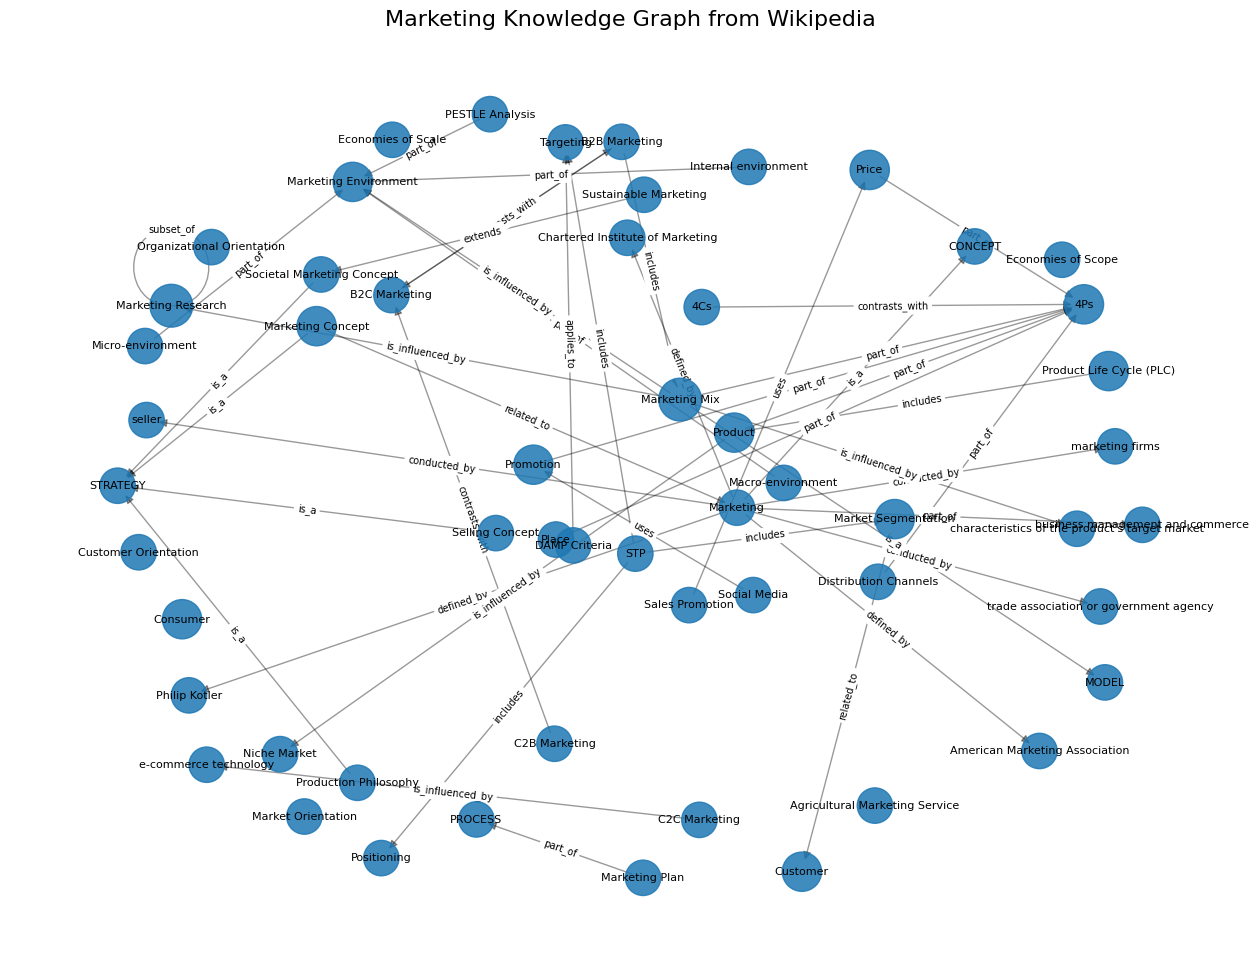

In [11]:
# ============================================================
# 10. Visualize Knowledge Graph
# ============================================================

def visualize_graph(G: nx.DiGraph, figsize=(16, 12), k=0.8):
    plt.figure(figsize=figsize)

    pos = nx.spring_layout(G, seed=42, k=k)

    node_sizes = [
        500 + 150 * G.nodes[n].get("mentions", 1)
        for n in G.nodes()
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        alpha=0.85
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=12,
        alpha=0.4
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=8
    )

    edge_labels = {
        (s, t): d.get("predicate", "")
        for s, t, d in G.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=7
    )

    plt.title("Marketing Knowledge Graph from Wikipedia", fontsize=16)
    plt.axis("off")
    plt.show()


visualize_graph(G)

## 11. Export the Knowledge Graph

This cell saves the graph in several standard formats for later analysis or visualization.

- JSON for programmatic use
- CSV for spreadsheet review
- GraphML and GEXF for graph tools such as Gephi and Neo4j

Exporting the graph makes it easy to share results and continue analysis outside this notebook.

In [12]:
# ============================================================
# 11. Export KG to JSON, CSV, GraphML, GEXF
# ============================================================

def serialize_graph(G: nx.DiGraph) -> Dict[str, Any]:
    nodes = []
    edges = []

    for n, data in G.nodes(data=True):
        nodes.append({
            "id": n,
            "type": data.get("type", ""),
            "description": data.get("description", ""),
            "aliases": sorted(list(data.get("aliases", []))) if isinstance(data.get("aliases"), set) else data.get("aliases", []),
            "source_docs": sorted(list(data.get("source_docs", []))) if isinstance(data.get("source_docs"), set) else data.get("source_docs", []),
            "source_urls": sorted(list(data.get("source_urls", []))) if isinstance(data.get("source_urls"), set) else data.get("source_urls", []),
            "mentions": data.get("mentions", 1),
        })

    for s, t, data in G.edges(data=True):
        evidence = data.get("evidence", [])
        if isinstance(evidence, str):
            evidence = [evidence]

        edges.append({
            "source": s,
            "target": t,
            "predicate": data.get("predicate", ""),
            "evidence": evidence[0] if evidence else "",
            "all_evidence": evidence,
            "confidence": data.get("confidence", None),
            "source_doc": data.get("source_doc", ""),
            "source_url": data.get("source_url", ""),
        })

    return {
        "metadata": {
            "source": WIKI_URL,
            "description": "Marketing knowledge graph constructed from the Wikipedia Marketing page.",
            "num_nodes": G.number_of_nodes(),
            "num_edges": G.number_of_edges(),
        },
        "nodes": nodes,
        "edges": edges,
    }


kg_data = serialize_graph(G)

with open("marketing_kg.json", "w", encoding="utf-8") as f:
    json.dump(kg_data, f, indent=2, ensure_ascii=False)

nodes_df = pd.DataFrame(kg_data["nodes"])
edges_df = pd.DataFrame(kg_data["edges"])

nodes_df.to_csv("marketing_kg_nodes.csv", index=False)
edges_df.to_csv("marketing_kg_edges.csv", index=False)

G_export = nx.DiGraph()

for n, data in G.nodes(data=True):
    clean_attrs = {}
    for k, v in data.items():
        if isinstance(v, set):
            clean_attrs[k] = "; ".join(sorted(list(v)))
        elif isinstance(v, list):
            clean_attrs[k] = "; ".join(map(str, v))
        else:
            clean_attrs[k] = v
    G_export.add_node(n, **clean_attrs)

for s, t, data in G.edges(data=True):
    clean_attrs = {}
    for k, v in data.items():
        if isinstance(v, set):
            clean_attrs[k] = "; ".join(sorted(list(v)))
        elif isinstance(v, list):
            clean_attrs[k] = "; ".join(map(str, v))
        else:
            clean_attrs[k] = v
    G_export.add_edge(s, t, **clean_attrs)

nx.write_graphml(G_export, "marketing_kg.graphml")
nx.write_gexf(G_export, "marketing_kg.gexf")

print("Exported files:")
print("- marketing_kg.json")
print("- marketing_kg_nodes.csv")
print("- marketing_kg_edges.csv")
print("- marketing_kg.graphml")
print("- marketing_kg.gexf")

Exported files:
- marketing_kg.json
- marketing_kg_nodes.csv
- marketing_kg_edges.csv
- marketing_kg.graphml
- marketing_kg.gexf


## 12. Gold Reference for Tutorial Evaluation

This section loads a curated gold-standard reference graph and evaluates extraction quality.

The gold reference helps learners compare the generated KG against a known correct set of concepts and relations.

What this step shows:

- how many expected marketing concepts were recovered
- how many relation pairs match the gold reference
- precision, recall, and F1 scores for nodes and edges

In [13]:
# ============================================================
# Load uploaded/output Marketing KG JSON and evaluate it
# ============================================================

import json
import re
import networkx as nx
from typing import Dict, Any

# Change this path if your file name is different
KG_JSON_PATH = "marketing_kg_outputs/marketing_kg.json"

with open(KG_JSON_PATH, "r", encoding="utf-8") as f:
    kg = json.load(f)

G_eval = nx.DiGraph()

for node in kg["nodes"]:
    G_eval.add_node(node["id"], **node)

for edge in kg["edges"]:
    G_eval.add_edge(
        edge["source"],
        edge["target"],
        predicate=edge.get("predicate", ""),
        evidence=edge.get("evidence", ""),
        source_doc=edge.get("source_doc", ""),
        source_url=edge.get("source_url", ""),
    )

print("Loaded evaluation graph")
print("Nodes:", G_eval.number_of_nodes())
print("Edges:", G_eval.number_of_edges())

Loaded evaluation graph
Nodes: 54
Edges: 40


In [14]:

GOLD_ENTITIES = {
    # 48 entities present in generated KG
    "Marketing",
    "Business Management",
    "B2B Marketing",
    "B2C Marketing",
    "Marketing Firms",
    "Trade Association",
    "Government Agency",
    "Market Orientation",
    "Marketing Mix",
    "Marketing Research",
    "Philip Kotler",
    "Sales Process Engineering",
    "Chartered Institute of Marketing",
    "Marketing Science",
    "Marketing Concept",
    "Needs",
    "Wants",
    "Demands",
    "Market Segmentation",
    "Needs-based Segmentation",
    "C2B Marketing",
    "C2C Marketing",
    "B2B Product Purchasers",
    "Marketing Management Orientations",
    "Product Concept",
    "Production Concept",
    "Production Philosophy",
    "Selling Concept",
    "Customer Orientation",
    "Organizational Orientation",
    "Societal Marketing Concept",
    "Sustainable Marketing",
    "Marketing Plan",
    "4Ps",
    "Product",
    "Price",
    "Place",
    "Promotion",
    "Distribution Channels",
    "4Cs",
    "Marketing Environment",
    "PESTLE Analysis",
    "Macro-environment",
    "Micro-environment",
    "Internal environment",
    "STP",
    "DAMP Criteria",
    "Product Life Cycle (PLC)",

    # 6 important but missing/near-missing concepts
    "Customer",
    "Consumer",
    "Target Market",
    "Segmentation",
    "Targeting",
    "Positioning",
}


GOLD_EDGE_PAIRS = {
    # 35 relation pairs present in generated KG
    ("Marketing", "Business Management"),
    ("Marketing", "B2B Marketing"),
    ("Marketing", "B2C Marketing"),
    ("Marketing", "Marketing Firms"),
    ("Marketing", "Trade Association"),
    ("Marketing", "Government Agency"),
    ("Marketing", "Market Orientation"),
    ("Marketing", "Marketing Science"),

    ("B2B Marketing", "B2B Product Purchasers"),
    ("B2B Marketing", "B2C Marketing"),
    ("C2B Marketing", "B2C Marketing"),

    ("Marketing Mix", "Marketing Research"),
    ("Marketing Mix", "4Ps"),

    ("Philip Kotler", "Marketing"),
    ("Sales Process Engineering", "Marketing"),
    ("Chartered Institute of Marketing", "Marketing"),

    ("Marketing Concept", "Marketing"),
    ("Marketing Concept", "Customer Orientation"),
    ("Marketing Concept", "Organizational Orientation"),

    ("Market Segmentation", "Needs"),
    ("Market Segmentation", "Wants"),
    ("Market Segmentation", "Demands"),
    ("Market Segmentation", "STP"),
    ("Needs-based Segmentation", "Market Segmentation"),

    ("Marketing Management Orientations", "Product Concept"),
    ("Marketing Management Orientations", "Production Concept"),

    ("Societal Marketing Concept", "Sustainable Marketing"),
    ("Marketing Plan", "Marketing Mix"),

    ("4Ps", "Product"),
    ("4Ps", "Price"),
    ("4Ps", "Place"),
    ("4Ps", "Promotion"),
    ("4Cs", "4Ps"),

    ("Micro-environment", "Macro-environment"),
    ("Internal environment", "Micro-environment"),

    # 5 important missing/near-missing relation pairs
    ("Marketing", "Customer"),
    ("Marketing", "Consumer"),
    ("STP", "Segmentation"),
    ("STP", "Targeting"),
    ("STP", "Positioning"),
}

In [15]:
# ============================================================
# Precision / Recall / F1 Evaluation
# ============================================================

EVAL_ALIASES = {
    "marketing mix": "Marketing Mix",
    "marketing research": "Marketing Research",
    "market research": "Marketing Research",

    "market segmentation": "Market Segmentation",

    "damp": "DAMP Criteria",
    "damp criteria": "DAMP Criteria",

    "4ps": "4Ps",
    "4 ps": "4Ps",
    "four ps": "4Ps",

    "4cs": "4Cs",
    "4 cs": "4Cs",
    "four cs": "4Cs",

    "product life cycle": "Product Life Cycle (PLC)",
    "product lifecycle": "Product Life Cycle (PLC)",
    "plc": "Product Life Cycle (PLC)",

    "macro environment": "Macro-environment",
    "micro environment": "Micro-environment",
    "internal environment": "Internal environment",

    "target market": "Target Market",
}

def normalize_for_eval(x: str) -> str:
    key = re.sub(r"[^a-zA-Z0-9]+", " ", x.strip().lower()).strip()
    return EVAL_ALIASES.get(key, x.strip())


def prf(pred: set, gold: set) -> Dict[str, Any]:
    tp = len(pred & gold)
    fp = len(pred - gold)
    fn = len(gold - pred)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }


pred_entities = {
    normalize_for_eval(n)
    for n in G_eval.nodes()
}

gold_entities = {
    normalize_for_eval(n)
    for n in GOLD_ENTITIES
}

pred_edge_pairs = {
    (normalize_for_eval(s), normalize_for_eval(t))
    for s, t, d in G_eval.edges(data=True)
}

gold_edge_pairs = {
    (normalize_for_eval(s), normalize_for_eval(t))
    for s, t in GOLD_EDGE_PAIRS
}

entity_scores = prf(pred_entities, gold_entities)
edge_scores = prf(pred_edge_pairs, gold_edge_pairs)

print("Entity scores:")
print(json.dumps(entity_scores, indent=2))

print("\nRelation pair scores:")
print(json.dumps(edge_scores, indent=2))

print("\nMissing silver entities:")
print(sorted(gold_entities - pred_entities))

print("\nMissing silver edge pairs:")
print(sorted(gold_edge_pairs - pred_edge_pairs))

Entity scores:
{
  "precision": 0.8888888888888888,
  "recall": 0.8888888888888888,
  "f1": 0.8888888888888888,
  "tp": 48,
  "fp": 6,
  "fn": 6
}

Relation pair scores:
{
  "precision": 0.875,
  "recall": 0.875,
  "f1": 0.875,
  "tp": 35,
  "fp": 5,
  "fn": 5
}

Missing silver entities:
['Consumer', 'Customer', 'Positioning', 'Segmentation', 'Target Market', 'Targeting']

Missing silver edge pairs:
[('Marketing', 'Consumer'), ('Marketing', 'Customer'), ('STP', 'Positioning'), ('STP', 'Segmentation'), ('STP', 'Targeting')]


In [16]:
# ============================================================
# 15. Present Evaluation as a DataFrame
# ============================================================

results_df = pd.DataFrame([
    {
        "Task": "Entity Extraction",
        "Precision": entity_scores["precision"],
        "Recall": entity_scores["recall"],
        "F1": entity_scores["f1"],
        "TP": entity_scores["tp"],
        "FP": entity_scores["fp"],
        "FN": entity_scores["fn"],
    },
    {
        "Task": "Relation Pair Extraction",
        "Precision": edge_scores["precision"],
        "Recall": edge_scores["recall"],
        "F1": edge_scores["f1"],
        "TP": edge_scores["tp"],
        "FP": edge_scores["fp"],
        "FN": edge_scores["fn"],
    },

])

results_df

,Task,Precision,Recall,F1,TP,FP,FN
0,Entity Extraction,0.888889,0.888889,0.888889,48,6,6
1,Relation Pair Extraction,0.875000,0.875000,0.875000,35,5,5


Tutorial triples:
Marketing --includes--> B2B Marketing
Marketing --includes--> B2C Marketing
Marketing --guided_by--> Market Orientation
Marketing --conducted_by--> Marketing Firms
Marketing Mix --includes--> 4Ps
Marketing Mix --is_influenced_by--> Marketing Research
4Ps --has_component--> Product
4Ps --has_component--> Price
4Ps --has_component--> Place
4Ps --has_component--> Promotion
Market Segmentation --part_of--> STP
DAMP Criteria --applies_to--> Market Segmentation
Marketing Concept --includes--> Customer Orientation
Marketing Concept --includes--> Organizational Orientation
Product Life Cycle (PLC) --uses--> Marketing Research


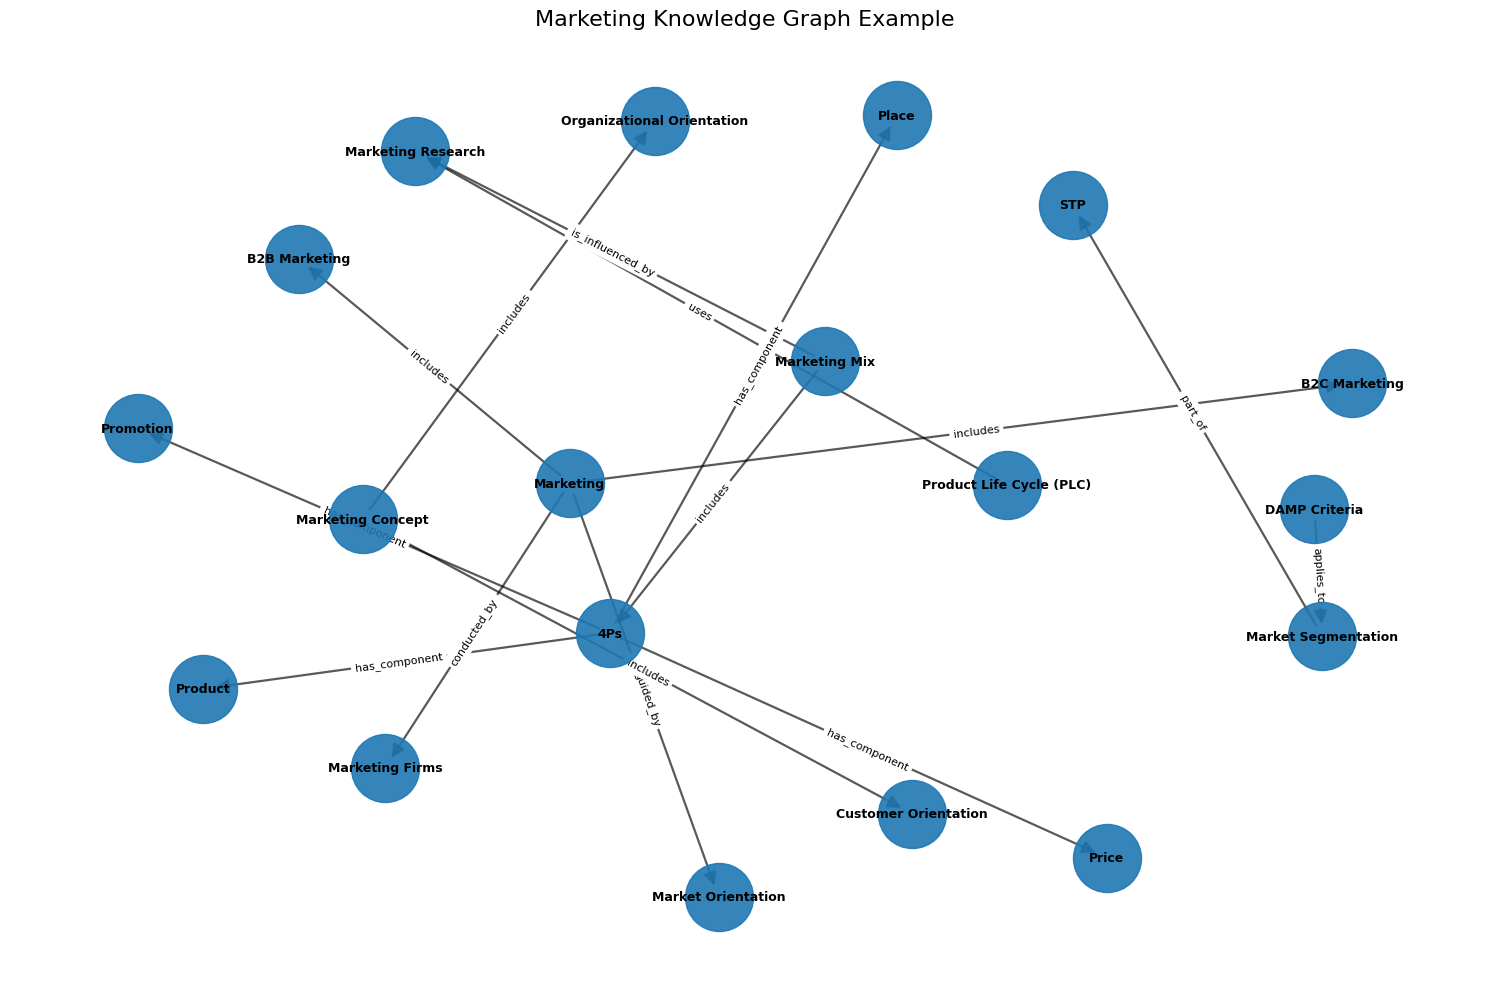

In [17]:
# ============================================================
# Hand-picked tutorial subgraph for clear presentation
# ============================================================

import matplotlib.pyplot as plt
import networkx as nx

TUTORIAL_TRIPLES = [
    ("Marketing", "includes", "B2B Marketing"),
    ("Marketing", "includes", "B2C Marketing"),
    ("Marketing", "guided_by", "Market Orientation"),
    ("Marketing", "conducted_by", "Marketing Firms"),

    ("Marketing Mix", "includes", "4Ps"),
    ("Marketing Mix", "is_influenced_by", "Marketing Research"),

    ("4Ps", "has_component", "Product"),
    ("4Ps", "has_component", "Price"),
    ("4Ps", "has_component", "Place"),
    ("4Ps", "has_component", "Promotion"),

    ("Market Segmentation", "part_of", "STP"),
    ("DAMP Criteria", "applies_to", "Market Segmentation"),

    ("Marketing Concept", "includes", "Customer Orientation"),
    ("Marketing Concept", "includes", "Organizational Orientation"),

    ("Product Life Cycle (PLC)", "uses", "Marketing Research"),
]

G_tutorial = nx.DiGraph()

for head, relation, tail in TUTORIAL_TRIPLES:
    G_tutorial.add_edge(head, tail, predicate=relation)

print("Tutorial triples:")
for head, tail, data in G_tutorial.edges(data=True):
    print(f"{head} --{data['predicate']}--> {tail}")

plt.figure(figsize=(15, 10))

pos = nx.spring_layout(G_tutorial, seed=7, k=1.4)

nx.draw_networkx_nodes(
    G_tutorial,
    pos,
    node_size=2400,
    alpha=0.9
)

nx.draw_networkx_edges(
    G_tutorial,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=20,
    width=1.6,
    alpha=0.65
)

nx.draw_networkx_labels(
    G_tutorial,
    pos,
    font_size=9,
    font_weight="bold"
)

edge_labels = {
    (head, tail): data["predicate"]
    for head, tail, data in G_tutorial.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G_tutorial,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.52
)

plt.title("Marketing Knowledge Graph Example", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()